# Portfolio Divergence Microcosm (Notebook)

 - **Author:** Tim Pinard
 - **Website:** [timpinard.com](https://timpinard.com)
 - **LinkedIn:** [linkedin.com/timpinard](https://linkedin.com/in/tim-pinard-a64695192)
 - **Project Repository:** [github.com/timpinard/portfolio-anomaly-detection](https://github.com/timpinard/portfolio-anomaly-detection)

---

This notebook is a **self-contained microcosm** of the portfolio structural divergence system.

It demonstrates (with **synthetic but market-like data**) the end-to-end flow:

1. Create a **universe** of assets and a market proxy  
2. Generate returns with latent factors (market + sector + idiosyncratic behavior)  
3. Build **cross-sectional, universe-relative features**  
4. Train a small **autoencoder** on the universe feature space  
5. Score the universe daily and compute **market-level summary statistics**  
6. Analyze portfolios:
   - **Structural divergence** (weighted AE reconstruction error)
   - **Directional divergence** (portfolio return vs market return)
   - **Attribution** (which holdings drive structure)

The point is not to “predict” returns. The point is to produce an **interpretable diagnostic**:
- *Is this portfolio structurally coherent relative to the universe?*
- *If not, which constituents are driving the divergence?*

> Note: Because the data is synthetic, your exact numbers will differ from your production system,
but the logic and outputs match the conceptual architecture.

In [1]:
# --- Imports & Settings ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler

np.random.seed(7)
torch.manual_seed(7)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

## 1) Create a Synthetic Market Universe

We create:
- A market proxy series ("SPY-like")
- A universe of assets with sector exposures
- Returns driven by:
  - market factor
  - sector factor
  - idiosyncratic noise
  - and optionally "erratic" behavior for select names

We'll label a few well-known tickers to make portfolio examples intuitive.

In [2]:
# --- Universe Setup ---
n_assets = 60
n_days = 520  # ~2 years of trading days
dates = pd.bdate_range("2024-01-02", periods=n_days)

# Choose some recognizable symbols + fill the rest
named = ["AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","JNJ","PG","KO","PEP","XOM","JPM","HD","UNH"]
symbols = named + [f"STK{i:02d}" for i in range(n_assets - len(named))]

# Assign sectors (simple)
sectors = ["TECH","TECH","TECH","TECH","TECH","TECH","TECH","DEF","DEF","DEF","DEF","ENE","FIN","CNS","HLT"]
sectors += list(np.random.choice(["TECH","DEF","FIN","ENE","CNS","HLT"], size=n_assets-len(sectors)))

asset_meta = pd.DataFrame({"symbol": symbols, "sector": sectors})
asset_meta.head(10)

,symbol,sector
0,AAPL,TECH
1,MSFT,TECH
2,GOOGL,TECH
3,AMZN,TECH
4,META,TECH
5,NVDA,TECH
6,TSLA,TECH
7,JNJ,DEF
8,PG,DEF
9,KO,DEF


In [3]:
# --- Generate Market and Sector Factors ---
base_sigma = 0.01
sigma = base_sigma * (1 + 0.8*np.sin(np.linspace(0, 8*np.pi, n_days))**2)
market_ret = np.random.normal(loc=0.0002, scale=sigma, size=n_days)

sector_names = sorted(asset_meta["sector"].unique())
sector_factor = {s: np.random.normal(0, 0.004, size=n_days) for s in sector_names}

beta_market = np.clip(np.random.normal(1.0, 0.25, size=n_assets), 0.2, 1.8)
beta_sector = np.clip(np.random.normal(0.7, 0.25, size=n_assets), 0.0, 1.5)

# Defensive names lower beta
for sym in ["JNJ","PG","KO","PEP"]:
    idx = symbols.index(sym)
    beta_market[idx] = np.clip(np.random.normal(0.55, 0.08), 0.3, 0.8)

# Erratic behavior for TSLA
erratic_symbol = "TSLA"

rets = np.zeros((n_days, n_assets))
for i, sym in enumerate(symbols):
    sec = asset_meta.loc[asset_meta.symbol==sym, "sector"].iloc[0]
    idio = np.random.normal(0, 0.012, size=n_days)

    r = beta_market[i]*market_ret + beta_sector[i]*sector_factor[sec] + idio

    if sym == erratic_symbol:
        burst = np.zeros(n_days)
        burst_days = np.random.choice(np.arange(40, n_days-40), size=6, replace=False)
        for d in burst_days:
            burst[d:d+5] += np.random.normal(-0.03, 0.01)
        decorrel = np.ones(n_days)
        for d in np.random.choice(np.arange(60, n_days-60), size=4, replace=False):
            decorrel[d:d+25] *= 0.2
        r = (beta_market[i]*decorrel)*market_ret + beta_sector[i]*sector_factor[sec] + idio + burst

    rets[:, i] = r

returns = pd.DataFrame(rets, index=dates, columns=symbols)
market = pd.Series(market_ret, index=dates, name="SPY")

returns.head()

,AAPL,MSFT,GOOGL,AMZN,META,NVDA,TSLA,JNJ,PG,KO,PEP,XOM,JPM,HD,UNH,STK00,STK01,STK02,STK03,STK04,STK05,STK06,STK07,STK08,STK09,...,STK20,STK21,STK22,STK23,STK24,STK25,STK26,STK27,STK28,STK29,STK30,STK31,STK32,STK33,STK34,STK35,STK36,STK37,STK38,STK39,STK40,STK41,STK42,STK43,STK44
2024-01-02,-0.020597,-0.024881,-0.059673,-0.042219,-0.020077,0.002130,-0.010393,0.004610,-0.001554,-0.005250,-0.008760,-0.014568,-0.034809,-0.004074,-0.033767,-0.022946,-0.029277,-0.020680,-0.052087,-0.030520,-0.027104,-0.040949,-0.035052,-0.027306,-0.019719,...,-0.020713,-0.033095,-0.024215,-0.025325,-0.041408,-0.014025,-0.017782,-0.017276,-0.021628,-0.015791,-0.010410,-0.034265,-0.022746,-0.020971,-0.019821,-0.026526,-0.018613,-0.028633,-0.024972,-0.031954,-0.025980,-0.007803,-0.024230,-0.019488,-0.043876
2024-01-03,-0.000923,0.002069,-0.013374,0.005093,0.015027,-0.005074,0.010542,-0.006207,0.005628,0.011902,0.013632,-0.007880,-0.001181,0.002835,0.011642,-0.010554,0.000874,-0.012151,0.012322,0.008426,0.011519,0.011063,-0.015337,0.015845,-0.003445,...,-0.014199,0.007751,-0.006336,0.023390,0.003750,-0.020782,-0.014406,-0.002728,0.004396,-0.014608,-0.001235,-0.023681,0.011720,-0.010599,-0.024149,0.016700,-0.014118,-0.005221,0.001226,0.003445,0.002757,-0.002019,0.008870,-0.007042,-0.002591
2024-01-04,-0.003107,0.010225,0.011282,0.016228,0.010055,0.018290,0.032396,0.002607,-0.012644,-0.008585,0.016444,0.017213,-0.020435,0.009861,0.019373,0.000904,0.012214,-0.002919,0.005371,0.004257,-0.016505,0.013992,0.009319,0.007404,-0.011228,...,0.025266,0.032402,0.009455,0.006236,0.001133,0.008665,0.009827,-0.006273,0.001843,-0.014145,0.001754,-0.002930,0.004820,-0.018623,-0.001493,-0.018556,0.009588,-0.000506,0.003456,0.007914,0.003009,0.026389,0.011215,0.002512,-0.000110
2024-01-05,-0.004960,-0.009384,0.007990,0.005498,0.026656,-0.001785,0.003851,-0.005907,0.003061,-0.017096,-0.014910,0.024077,-0.000626,0.008258,0.028181,0.029564,0.007738,0.006251,-0.006393,0.010557,0.004895,0.010528,0.021861,0.005473,0.007887,...,-0.000525,0.008806,0.010620,0.005707,-0.004521,0.001877,0.000831,0.002447,-0.000301,0.002174,0.012042,-0.007780,0.005361,0.020629,0.021651,0.018789,-0.002594,-0.005638,0.007655,0.008349,0.020367,0.004181,0.005961,0.016978,0.010857
2024-01-08,-0.015753,0.038852,0.015832,0.014256,0.015068,0.017603,0.026203,0.001659,-0.010136,0.019095,0.032690,0.007123,0.002529,0.009186,0.018325,-0.000425,0.026627,-0.020519,0.008790,-0.021705,0.006961,0.011350,0.012134,0.011124,0.003880,...,0.005341,0.029648,0.000664,-0.001060,0.025323,0.022486,0.026631,0.002093,-0.014241,0.008654,-0.009712,-0.019155,0.036845,-0.013438,0.018530,0.006002,-0.019099,0.000191,-0.003214,0.006611,0.017583,0.025338,0.022441,0.010614,0.007728


## 2) Build Cross-Sectional Features (Simplified)

We compute a small set of **universe-relative features**:

- relative_return_5d: asset 5d return minus universe mean 5d return
- corr_20d: rolling correlation vs market
- corr_change_20d: corr_t - corr_{t-5}
- beta_60d: rolling beta vs market
- rank_extremity_5d: distance from median rank (0..1)
- zscore_vs_universe_20d: z-score of 20d return vs universe

We compute these per (date, symbol).

In [ ]:
def rolling_return(df, window):
    return (1 + df).rolling(window).apply(np.prod, raw=True) - 1

r5  = rolling_return(returns, 5)
r20 = rolling_return(returns, 20)

r5_u_mean  = r5.mean(axis=1)
r20_u_mean = r20.mean(axis=1)

relative_return_5d = r5.sub(r5_u_mean, axis=0)

corr_20d = returns.rolling(20).corr(market).unstack(level=1)
corr_20d = corr_20d[symbols]
corr_change_20d = corr_20d - corr_20d.shift(5)

mkt_var_60 = market.rolling(60).var()
cov_60 = returns.rolling(60).cov(market)
beta_60d = cov_60.div(mkt_var_60, axis=0)

rank_5d = r5.rank(axis=1, pct=True)
rank_extremity_5d = (rank_5d - 0.5).abs() * 2

r20_u_std = r20.std(axis=1).replace(0, np.nan)
zscore_vs_universe_20d = r20.sub(r20_u_mean, axis=0).div(r20_u_std, axis=0)

feat = pd.DataFrame({"date": np.repeat(dates.values, n_assets), "symbol": symbols * n_days})
# Ensure date column is datetime64[ns] - force conversion
feat['date'] = pd.to_datetime(feat['date']).astype('datetime64[ns]')

def stack_df(df, name):
    # Handle both Series and DataFrame inputs
    if isinstance(df, pd.Series):
        # If Series has MultiIndex (date, symbol), convert directly
        if isinstance(df.index, pd.MultiIndex):
            result = df.rename(name).reset_index()
            # After reset_index(), we have level_0, level_1, and the value
            # Need to determine which level is dates and which is symbols
            level_0_col = result.columns[0]
            level_1_col = result.columns[1]
            
            # Check which column contains dates
            try:
                level_0_parsed = pd.to_datetime(result[level_0_col].iloc[0], errors='coerce')
                level_1_parsed = pd.to_datetime(result[level_1_col].iloc[0], errors='coerce')
                level_0_is_date = pd.notna(level_0_parsed)
                level_1_is_date = pd.notna(level_1_parsed)
            except:
                level_0_is_date = False
                level_1_is_date = False
            
            # Rename columns based on what they actually contain
            if len(result.columns) == 3:  # level_0, level_1, value
                value_col = result.columns[2]
                if level_0_is_date and not level_1_is_date:
                    # Standard: level_0 = dates, level_1 = symbols
                    result = result.rename(columns={level_0_col: "date", level_1_col: "symbol", value_col: name})
                elif level_1_is_date and not level_0_is_date:
                    # Swapped: level_0 = symbols, level_1 = dates
                    result = result.rename(columns={level_0_col: "symbol", level_1_col: "date", value_col: name})
                else:
                    # Can't determine - assume standard order
                    result = result.rename(columns={level_0_col: "date", level_1_col: "symbol", value_col: name})
            else:
                # Fallback
                if level_0_is_date and not level_1_is_date:
                    result = result.rename(columns={"level_0": "date", "level_1": "symbol"})
                elif level_1_is_date and not level_0_is_date:
                    result = result.rename(columns={"level_0": "symbol", "level_1": "date"})
                else:
                    result = result.rename(columns={"level_0": "date", "level_1": "symbol"})
            
            # Ensure date is datetime64[ns] - use errors='coerce' to handle any issues
            if 'date' in result.columns:
                result['date'] = pd.to_datetime(result['date'], errors='coerce').astype('datetime64[ns]')
            return result
        else:
            # Series with single-level index - convert to DataFrame
            df = df.to_frame(name)
    
    # Now df is guaranteed to be a DataFrame
    # Check if DataFrame has only one column (can't stack meaningfully)
    if df.shape[1] == 1:
        # Single column - just reset index and rename
        result = df.reset_index()
        # Rename columns appropriately
        if len(result.columns) == 2:
            result = result.rename(columns={result.columns[0]: "date", result.columns[1]: name})
            # We need a symbol column - this shouldn't happen in normal flow
            # But we'll create a placeholder that will need to be handled upstream
            result['symbol'] = result.columns[1] if 'symbol' not in result.columns else result['symbol']
        # Ensure date is datetime64[ns] - force conversion
        if 'date' in result.columns:
            result['date'] = pd.to_datetime(result['date']).astype('datetime64[ns]')
        return result
    
    # Normal case: DataFrame with multiple columns (symbols) - stack it
    # When stacking: level_0 = index (dates), level_1 = columns (symbols)
    stacked = df.stack()
    # Rename the Series (result of stack) and convert to DataFrame
    result = stacked.rename(name).reset_index()
    
    # After reset_index(), columns are: level_0 (dates), level_1 (symbols), and the value
    # Verify which is which by checking if we can parse as datetime
    level_0_col = result.columns[0]
    level_1_col = result.columns[1]
    
    # Check which column contains dates
    try:
        level_0_parsed = pd.to_datetime(result[level_0_col].iloc[0], errors='coerce')
        level_1_parsed = pd.to_datetime(result[level_1_col].iloc[0], errors='coerce')
        level_0_is_date = pd.notna(level_0_parsed)
        level_1_is_date = pd.notna(level_1_parsed)
    except:
        level_0_is_date = False
        level_1_is_date = False
    
    # Rename columns based on what they actually contain
    if level_0_is_date and not level_1_is_date:
        # Standard case: level_0 = dates, level_1 = symbols
        result = result.rename(columns={level_0_col: "date", level_1_col: "symbol"})
    elif level_1_is_date and not level_0_is_date:
        # Swapped case: level_0 = symbols, level_1 = dates
        result = result.rename(columns={level_0_col: "symbol", level_1_col: "date"})
    else:
        # Can't determine - assume standard order
        result = result.rename(columns={level_0_col: "date", level_1_col: "symbol"})
    
    # Ensure date column is datetime64[ns]
    if 'date' in result.columns:
        # Convert to datetime, handling any type
        result['date'] = pd.to_datetime(result['date'], errors='coerce').astype('datetime64[ns]')
    return result

feat = feat.merge(stack_df(relative_return_5d, "relative_return_5d"), on=["date","symbol"])
feat = feat.merge(stack_df(corr_20d, "corr_20d"), on=["date","symbol"])
feat = feat.merge(stack_df(corr_change_20d, "corr_change_20d"), on=["date","symbol"])
feat = feat.merge(stack_df(beta_60d, "beta_60d"), on=["date","symbol"])
feat = feat.merge(stack_df(rank_extremity_5d, "rank_extremity_5d"), on=["date","symbol"])
feat = feat.merge(stack_df(zscore_vs_universe_20d, "zscore_vs_universe_20d"), on=["date","symbol"])

feat = feat.dropna().reset_index(drop=True)
feat.head()

,date,symbol,relative_return_5d,corr_20d,corr_change_20d,beta_60d,rank_extremity_5d,zscore_vs_universe_20d
0,2024-03-25,AAPL,0.021465,0.674899,-0.112117,0.710741,0.700000,1.119820
1,2024-03-25,MSFT,0.021204,0.899962,-0.038860,1.123038,0.633333,0.340677
2,2024-03-25,GOOGL,0.028010,0.842138,-0.039065,1.094171,0.866667,0.230110
3,2024-03-25,AMZN,0.019255,0.897995,-0.013830,1.153664,0.566667,-1.390126
4,2024-03-25,META,0.044299,0.736854,0.007272,0.764806,0.933333,0.407355


## 3) Train a Tiny Autoencoder on Universe Features

We standardize features and train a small autoencoder.

**Interpretation:** the autoencoder learns the "normal" manifold of universe structure.
Reconstruction error becomes a **structural anomaly score**.

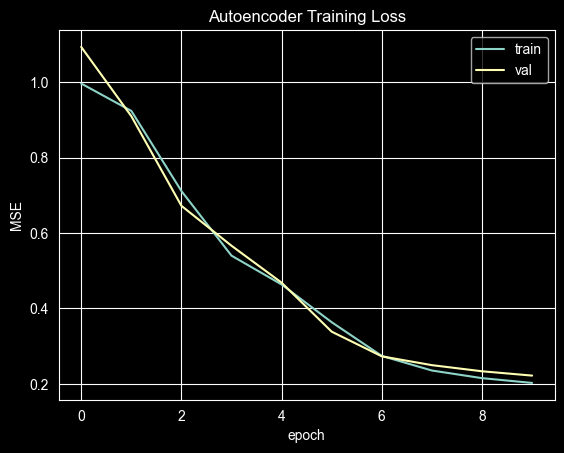

In [5]:
feature_cols = [
    "relative_return_5d",
    "corr_20d",
    "corr_change_20d",
    "beta_60d",
    "rank_extremity_5d",
    "zscore_vs_universe_20d"
]

X = feat[feature_cols].values.astype(np.float32)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

cut = int(len(feat) * 0.85)
X_train = X_scaled[:cut]
X_val   = X_scaled[cut:]

train_loader = DataLoader(TensorDataset(torch.tensor(X_train)), batch_size=512, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val)), batch_size=512, shuffle=False)

class AE(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d_in, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 3)
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 8), nn.ReLU(),
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, d_in)
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

device = torch.device("cpu")
model = AE(len(feature_cols)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

def run_epoch(loader, train=True):
    model.train(train)
    total, n = 0.0, 0
    for (xb,) in loader:
        xb = xb.to(device)
        if train:
            opt.zero_grad()
        recon = model(xb)
        loss = loss_fn(recon, xb)
        if train:
            loss.backward()
            opt.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    return total / max(n, 1)

train_losses, val_losses = [], []
for epoch in range(10):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)
    train_losses.append(tr); val_losses.append(va)

plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.show()

## 4) Score the Universe and Compute Daily Market Summaries

Score = per-row reconstruction error. Then compute daily universe summary statistics:
- mean
- std
- p95/p99

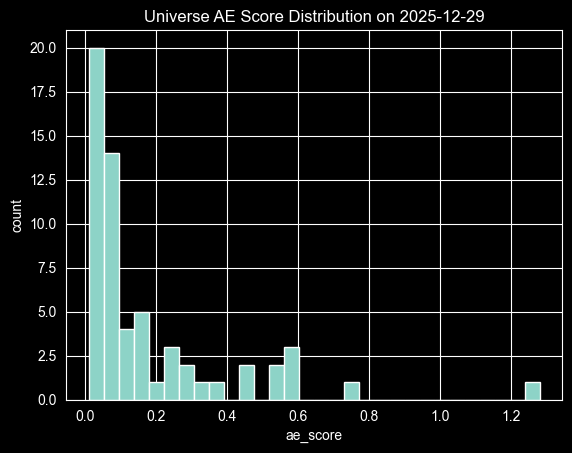

,date,mean,std,p95,p99
456,2025-12-23,0.146347,0.128029,0.352132,0.552487
457,2025-12-24,0.155600,0.166781,0.490756,0.692007
458,2025-12-25,0.163388,0.184438,0.537705,0.823589
459,2025-12-26,0.177317,0.209977,0.528300,0.902093
460,2025-12-29,0.181878,0.230120,0.570549,0.964908


In [6]:
model.eval()
with torch.no_grad():
    X_all_t = torch.tensor(X_scaled).to(device)
    recon = model(X_all_t).cpu().numpy()

row_mse = np.mean((recon - X_scaled)**2, axis=1)

scored = feat[["date","symbol"]].copy()
scored["ae_score"] = row_mse

daily = scored.groupby("date")["ae_score"].agg(["mean","std"])
daily["p95"] = scored.groupby("date")["ae_score"].quantile(0.95)
daily["p99"] = scored.groupby("date")["ae_score"].quantile(0.99)
daily = daily.reset_index()

analysis_date = scored["date"].iloc[-20]
day_scores = scored.loc[scored["date"]==analysis_date, "ae_score"]

plt.figure()
plt.hist(day_scores, bins=30)
plt.title(f"Universe AE Score Distribution on {pd.to_datetime(analysis_date).date()}")
plt.xlabel("ae_score"); plt.ylabel("count")
plt.show()

daily.tail()

## 5) Portfolio Analysis (Structural + Directional + Attribution)

We define a small `analyze_portfolio_health` function analogous to your service:
- Structural score = weighted sum of AE scores
- Structural z-score = normalized vs universe mean/std on that date
- Contra return = portfolio return minus market return (k-day)
- Directional z-score = contra return normalized by market realized vol
- Contributors = per-asset contributions (w * ae_score)

In [7]:
def portfolio_return(holdings, date, horizon=5):
    d = pd.to_datetime(date)
    idx = returns.index.get_loc(d)
    start = max(0, idx-horizon+1)
    r = returns.iloc[start:idx+1]
    w = np.array([h["weight"] for h in holdings], dtype=float)
    syms = [h["symbol"] for h in holdings]
    w = w / w.sum()
    pr = (1 + (r[syms] @ w)).prod() - 1
    return float(pr)

def market_return(date, horizon=5):
    d = pd.to_datetime(date)
    idx = market.index.get_loc(d)
    start = max(0, idx-horizon+1)
    mr = (1 + market.iloc[start:idx+1]).prod() - 1
    return float(mr)

def analyze_portfolio_health(holdings, analysis_date, contra_horizon=5):
    # normalize weights
    w = np.array([h["weight"] for h in holdings], dtype=float)
    syms = [h["symbol"] for h in holdings]
    w = w / w.sum()

    # structural scores for date
    ds = scored[scored["date"]==np.datetime64(analysis_date)].set_index("symbol").reindex(syms)
    missing = ds["ae_score"].isna()
    if missing.any():
        raise ValueError(f"Missing scores for symbols: {list(np.array(syms)[missing.values])}")

    ae = ds["ae_score"].values.astype(float)
    portfolio_score = float(np.sum(w * ae))

    contributors = pd.DataFrame({
        "symbol": syms,
        "weight": w,
        "ae_score": ae,
        "contribution": w * ae
    }).sort_values("contribution", ascending=False)

    # normalize structural vs universe
    dsum = daily.loc[daily["date"]==np.datetime64(analysis_date)].iloc[0]
    mu = float(dsum["mean"])
    sig = float(dsum["std"]) if float(dsum["std"]) > 1e-12 else 1e-12
    structural_z = (portfolio_score - mu) / sig

    # directional
    pr = portfolio_return(holdings, analysis_date, horizon=contra_horizon)
    mr = market_return(analysis_date, horizon=contra_horizon)
    contra = pr - mr

    # market vol proxy
    d = pd.to_datetime(analysis_date)
    idx = market.index.get_loc(d)
    start = max(0, idx-60)
    mkt_vol = float(market.iloc[start:idx+1].std())
    directional_z = contra / max(mkt_vol, 1e-12)

    # combined diagnostic (simple)
    health = structural_z + directional_z

    return {
        "date": str(pd.to_datetime(analysis_date).date()),
        "portfolio_score": portfolio_score,
        "structural_z": float(structural_z),
        "contra_return": float(contra),
        "directional_z": float(directional_z),
        "health_score": float(health),
        "contributors": contributors.to_dict(orient="records")
    }

## 6) Demonstration Portfolios

We test three cases:

1. **Coherent TECH** (large-cap tech basket)  
2. **Coherent Defensive** (staples/defensive basket)  
3. **Erratic Small-Weight Hijack** (TSLA at small weight dominates structure)  

Expectation:
- Coherent portfolios: contributions track weights reasonably
- Erratic case: a small-weight name dominates contributions via unusually high AE score

In [8]:
analysis_date = pd.to_datetime(scored["date"].iloc[-20]).date().isoformat()

p_tech = [
    {"symbol":"AAPL","weight":0.25},
    {"symbol":"MSFT","weight":0.25},
    {"symbol":"GOOGL","weight":0.20},
    {"symbol":"AMZN","weight":0.15},
    {"symbol":"META","weight":0.15},
]

p_def = [
    {"symbol":"JNJ","weight":0.30},
    {"symbol":"PG","weight":0.30},
    {"symbol":"KO","weight":0.20},
    {"symbol":"PEP","weight":0.20},
]

p_err = [
    {"symbol":"AAPL","weight":0.40},
    {"symbol":"MSFT","weight":0.40},
    {"symbol":"TSLA","weight":0.05},
    {"symbol":"NVDA","weight":0.05},
    {"symbol":"META","weight":0.10},
]

res_tech = analyze_portfolio_health(p_tech, analysis_date, contra_horizon=5)
res_def  = analyze_portfolio_health(p_def, analysis_date, contra_horizon=5)
res_err  = analyze_portfolio_health(p_err, analysis_date, contra_horizon=5)

pd.DataFrame([
    {"case":"TECH", **{k:res_tech[k] for k in ["portfolio_score","structural_z","contra_return","directional_z","health_score"]}},
    {"case":"DEF",  **{k:res_def[k]  for k in ["portfolio_score","structural_z","contra_return","directional_z","health_score"]}},
    {"case":"ERR",  **{k:res_err[k]  for k in ["portfolio_score","structural_z","contra_return","directional_z","health_score"]}},
])

,case,portfolio_score,structural_z,contra_return,directional_z,health_score
0,TECH,0.084269,-0.424164,0.002928,0.216561,-0.207603
1,DEF,0.248638,0.290113,0.003119,0.230681,0.520794
2,ERR,0.073151,-0.472479,0.013317,0.984950,0.512470


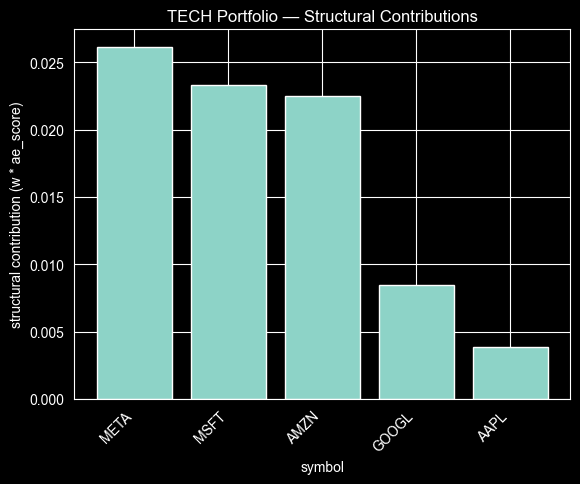

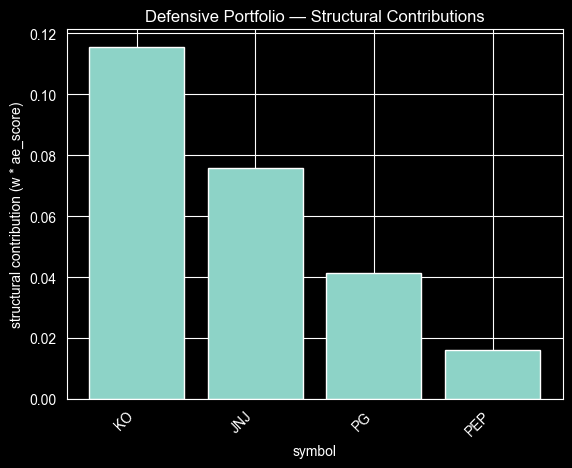

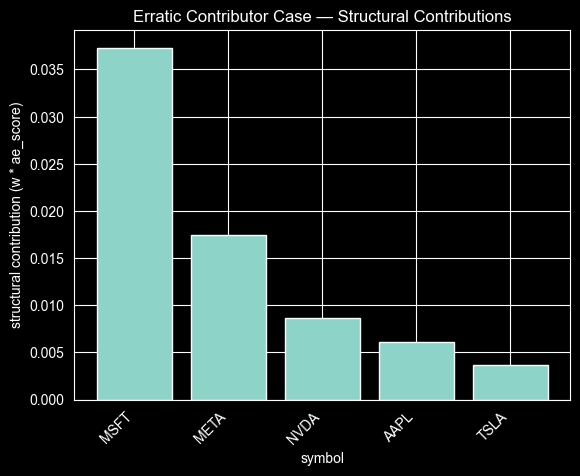

In [9]:
def plot_contributors(res, title):
    df = pd.DataFrame(res["contributors"]).copy()
    plt.figure()
    plt.bar(df["symbol"], df["contribution"])
    plt.title(title)
    plt.xlabel("symbol"); plt.ylabel("structural contribution (w * ae_score)")
    plt.xticks(rotation=45, ha="right")
    plt.show()

plot_contributors(res_tech, "TECH Portfolio — Structural Contributions")
plot_contributors(res_def, "Defensive Portfolio — Structural Contributions")
plot_contributors(res_err, "Erratic Contributor Case — Structural Contributions")

In [10]:
def summarize_case(res, name):
    contrib = pd.DataFrame(res["contributors"])
    top = contrib.iloc[0]
    print(f"--- {name} ---")
    print("date:", res["date"])
    print("portfolio_score:", res["portfolio_score"])
    print("structural_z:", res["structural_z"])
    print("contra_return:", res["contra_return"])
    print("directional_z:", res["directional_z"])
    print("health_score:", res["health_score"])
    print("")
    print("Top contributor:", dict(top))
    print("Top share of structural contributions:", float(top["contribution"] / contrib["contribution"].sum()))
    print()

summarize_case(res_tech, "TECH")
summarize_case(res_def, "DEFENSIVE")
summarize_case(res_err, "ERRATIC HIJACK")

--- TECH ---
date: 2025-12-29
portfolio_score: 0.08426937921904026
structural_z: -0.42416411270154847
contra_return: 0.002928039808133609
directional_z: 0.21656086510720074
health_score: -0.20760324759434773

Top contributor: {'symbol': 'META', 'weight': np.float64(0.15), 'ae_score': np.float64(0.17425788938999176), 'contribution': np.float64(0.026138683408498762)}
Top share of structural contributions: 0.3101800873666914

--- DEFENSIVE ---
date: 2025-12-29
portfolio_score: 0.24863841384649277
structural_z: 0.29011257611994307
contra_return: 0.0031189551059229714
directional_z: 0.2306811588056041
health_score: 0.5207937349255471

Top contributor: {'symbol': 'KO', 'weight': np.float64(0.2), 'ae_score': np.float64(0.5776166915893555), 'contribution': np.float64(0.1155233383178711)}
Top share of structural contributions: 0.46462385490117475

--- ERRATIC HIJACK ---
date: 2025-12-29
portfolio_score: 0.0731510918587446
structural_z: -0.4724793777943779
contra_return: 0.013317143190878733
dir

## 7) Mapping to the Full System

This microcosm matches your production architecture conceptually:

- **market_prices** → `returns` + `market` (synthetic)
- **features_divergence** → `feat` (cross-sectional features)
- **train_experiment.py** → AE training section
- **score_universe.py** → `scored` + `daily` universe summary
- **portfolio service** → `analyze_portfolio_health`

Next steps are the same:
- persist daily summaries
- backtest alert quality
- add regime conditioning
- optionally add IF and ensemble using daily z-score normalization